![title](img/SupFig4.jpg)

# Supplementary Figure 4
(a) Potential density on the 20°C isotherm surface in FOSI. Pink contour lines indicate the 24.4, 24.5, and 24.6 kg/m3 density levels, while cyan contour lines indicate the 24.9, 25.0, and 25.1 kg/m3 density levels. (b) Same as (a) but for the LENS 10-member mean of potential density on the 20°C isotherm surface. (c) Difference (LENS – FOSI) in potential density on the 20°C isotherm. Black contour lines indicate the -0.1, 0, and 0.1 kg/m3 difference in density levels. (d) FOSI potential density on the 20°C isotherm (representing the equatorial thermocline). (e) LENS 10-member potential density mean on the 20°C isotherm. (f) Depth of the 20°C isotherm at the equator (blue: LENS, red: FOSI).

# Imports and functions

#### Imports

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.collections as mcollections
import matplotlib.colors as colors
import numpy as np
import cmocean
import processing_utils as proc_utils
import cesm2_lens_utils
import analysis_funcs as afuncs
import xesmf as xe
import pop_tools
import cftime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import gaussian_kde

# PD, PV, and Depth of 20°C Isotherm fields

## Processing

In [36]:
def regrid_time_mean_popvar(ds, regridder, time_start, time_end):
    var_mean = ds.isel(time=slice(time_start,time_end)).isel(TEMP = 2).mean(dim='time').compute()
    var_1deg = proc_utils.regrid_SMYLE(var_mean)
    regridded_var = regridder(var_1deg)
    return regridded_var

In [37]:
time_start = 0; time_end = 240
# time_start = 456; time_end = 696

In [38]:
ensemble_members = [0, 65,  32, 85, 61, 90, 80, 68, 73, 49]

In [39]:
CESMLENS_var = afuncs.LENS_for_regridding()

## LENS data

In [32]:
##### ------------  LENS
##### POTENTIAL VORTICITY
file_paths = [f'/glade/derecho/scratch/cassiacai/regridded_PV_{member}.nc' for member in ensemble_members]
LENS_PV_all = xr.open_mfdataset(file_paths, combine='nested', concat_dim='ensemble')
LENS_PV_mean = LENS_PV_all.PV.isel(time=slice(time_start,time_end)).isel(TEMP = 2).mean(dim='time').compute()
LENS_PV_1deg = proc_utils.regrid_SMYLE(LENS_PV_mean)

regridder = xe.Regridder(LENS_PV_1deg, CESMLENS_var[:,:], 'nearest_s2d', periodic=True)

regridded_LENS_PV = np.absolute(regridder(LENS_PV_1deg))

##### POTENTIAL DENSITY
file_paths = [f'/glade/derecho/scratch/cassiacai/regridded_PD_{member}.nc' for member in ensemble_members]
LENS_PD_all = xr.open_mfdataset(file_paths, combine='nested', concat_dim='ensemble')

ds = LENS_PD_all.PD
regridded_LENS_PD = regrid_time_mean_popvar(ds, regridder, time_start, time_end)
regridded_LENS_PD_nan = xr.where(regridded_LENS_PD == 0., np.nan, regridded_LENS_PD)

##### TEMPERATURE
file_paths = [f'/glade/derecho/scratch/cassiacai/regridded_TEMP_{member}.nc' for member in ensemble_members]
LENS_TEMP_all = xr.open_mfdataset(file_paths, combine='nested', concat_dim='ensemble')

ds = LENS_TEMP_all.__xarray_dataarray_variable__
regridded_LENS_TEMP = regrid_time_mean_popvar(ds, regridder, time_start, time_end)
regridded_LENS_TEMP_nan = xr.where(regridded_LENS_TEMP == 0., np.nan, regridded_LENS_TEMP)

# ##### SST
# SST = atm_var_ens(ENS_MEMB, 'SST')
# SST_nan = xr.where(SST == 0., np.nan, SST) - 273.15

In [33]:
##### ------------  LENS
##### POTENTIAL VORTICITY
file_paths = [f'/glade/derecho/scratch/cassiacai/regridded_PV_{member}.nc' for member in ensemble_members]
LENS_PV_all = xr.open_mfdataset(file_paths, combine='nested', concat_dim='ensemble')
LENS_PV_mean = LENS_PV_all.PV.isel(time=slice(time_start,time_end)).isel(TEMP = 2).mean(dim='time').compute()
LENS_PV_1deg = proc_utils.regrid_SMYLE(LENS_PV_mean)

regridder = xe.Regridder(LENS_PV_1deg, CESMLENS_var[:,:], 'nearest_s2d', periodic=True)

regridded_LENS_PV = np.absolute(regridder(LENS_PV_1deg))


##### POTENTIAL DENSITY
file_paths = [f'/glade/derecho/scratch/cassiacai/regridded_PD_{member}.nc' for member in ensemble_members]
LENS_PD_all = xr.open_mfdataset(file_paths, combine='nested', concat_dim='ensemble')

ds = LENS_PD_all.PD
regridded_LENS_PD = regrid_time_mean_popvar(ds, regridder, time_start, time_end)
regridded_LENS_PD_nan = xr.where(regridded_LENS_PD == 0., np.nan, regridded_LENS_PD)


In [40]:
##### ------------  LENS
##### POTENTIAL VORTICITY
file_paths = [f'/glade/derecho/scratch/cassiacai/regridded_PV_{member}.nc' for member in ensemble_members]
LENS_PV_all = xr.open_mfdataset(file_paths, combine='nested', concat_dim='ensemble')
LENS_PV_mean = LENS_PV_all.PV.isel(time=slice(time_start,time_end)).isel(TEMP = 2).mean(dim='time').compute()
LENS_PV_1deg = proc_utils.regrid_SMYLE(LENS_PV_mean)

regridder = xe.Regridder(LENS_PV_1deg, CESMLENS_var[:,:], 'nearest_s2d', periodic=True)

regridded_LENS_PV = np.absolute(regridder(LENS_PV_1deg))


## FOSI data

In [34]:
##### ------------  FOSI
##### POTENTIAL VORTICITY
FOSI_PV = xr.open_dataset('/glade/derecho/scratch/cassiacai/regridded_PV_FOSI.nc')
FOSI_PV_mean = FOSI_PV.PV.isel(time=slice(time_start,time_end)).isel(TEMP = 2).mean(dim='time').compute()
FOSI_PV_1deg = proc_utils.regrid_SMYLE(FOSI_PV_mean)
regridded_FOSI_PV = np.absolute(regridder(FOSI_PV_1deg))

##### POTENTIAL DENSITY
FOSI_PD = xr.open_dataset('/glade/derecho/scratch/cassiacai/regridded_PD_FOSI_other.nc')
FOSI_PD_mean = FOSI_PD.PD.isel(time=slice(time_start,time_end)).isel(TEMP = 2).mean(dim='time').compute()
FOSI_PD_1deg = proc_utils.regrid_SMYLE(FOSI_PD_mean)
regridded_FOSI_PD = np.absolute(regridder(FOSI_PD_1deg))

##### TEMPERATURE
FOSI_TEMP = xr.open_dataset('/glade/derecho/scratch/cassiacai/regridded_TEMP_FOSI.nc')
FOSI_TEMP_mean = FOSI_TEMP.__xarray_dataarray_variable__.isel(time=slice(time_start,time_end)).isel(TEMP = 2).mean(dim='time').compute()
FOSI_TEMP_1deg = proc_utils.regrid_SMYLE(FOSI_TEMP_mean)
regridded_FOSI_TEMP = np.absolute(regridder(FOSI_TEMP_1deg))

In [41]:
##### ------------  FOSI
##### POTENTIAL VORTICITY
FOSI_PV = xr.open_dataset('/glade/derecho/scratch/cassiacai/regridded_PV_FOSI.nc')
FOSI_PV_mean = FOSI_PV.PV.isel(time=slice(time_start,time_end)).isel(TEMP = 2).mean(dim='time').compute()
FOSI_PV_1deg = proc_utils.regrid_SMYLE(FOSI_PV_mean)
regridded_FOSI_PV = np.absolute(regridder(FOSI_PV_1deg))

## Potential Density

In [36]:
regridded_FOSI_PD_nan = xr.where(regridded_FOSI_PD == 0., np.nan, regridded_FOSI_PD)
regridded_FOSI_PD_nan_noAtlantic = xr.where(regridded_FOSI_PD_nan > 25.95, np.nan, regridded_FOSI_PD_nan)

In [37]:
regridded_LENS_PD_nan = xr.where(regridded_LENS_PD == 0., np.nan, regridded_LENS_PD)
regridded_LENS_PD_nan_noAtlantic = xr.where(regridded_LENS_PD_nan > 25.95, np.nan, regridded_LENS_PD_nan)

In [38]:
diff = regridded_LENS_PD_nan_noAtlantic.mean(dim='ensemble') - regridded_FOSI_PD_nan_noAtlantic

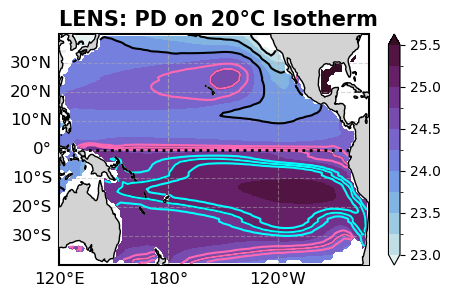

In [34]:
# LENS --------- Mean PD on 20°C Isotherm
fig, ax = plt.subplots(figsize=(5, 3), 
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 290, -40, 40], crs=ccrs.PlateCarree())
ax.set_aspect('auto')  # Override the equal aspect ratio

gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 12}  # Longitude labels
gl.ylabel_style = {'size': 12}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='dotted', linewidth=2, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)

regridded_LENS_PD_nan_noAtlantic.mean(dim='ensemble').sel(lat=slice(-40, 40), lon=slice(120,290)).plot.contourf(
    vmin=23, vmax=25.5, levels=11, cmap=cmocean.cm.dense, transform=ccrs.PlateCarree(), add_colorbar=True)

contour_obj = (regridded_LENS_PD_nan_noAtlantic.mean(dim='ensemble')).plot.contour(levels=[23, 23.5, 24, 24.5, 25, 25.5, 26], cmap='k',transform=ccrs.PlateCarree())
(regridded_LENS_PD_nan_noAtlantic.mean(dim='ensemble')).plot.contour(levels=[24.4, 24.5, 24.6], cmap='hotpink', transform=ccrs.PlateCarree())

(regridded_LENS_PD_nan_noAtlantic.mean(dim='ensemble')).plot.contour(levels=[24.9, 25.0, 25.1], cmap='cyan', transform=ccrs.PlateCarree())


plt.title('')
plt.title('LENS: PD on 20°C Isotherm', fontsize=15, fontweight='bold', zorder=12, loc='left')
plt.show()

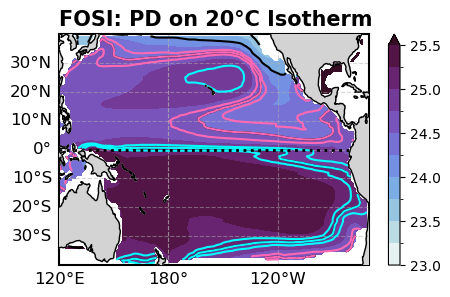

In [38]:
# FOSI --------- Mean PD on 20°C Isotherm
fig, ax = plt.subplots(figsize=(5, 3), 
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 290, -40, 40], crs=ccrs.PlateCarree())
ax.set_aspect('auto')  # Override the equal aspect ratio

gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 12}  # Longitude labels
gl.ylabel_style = {'size': 12}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='dotted', linewidth=2, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)

regridded_FOSI_PD_nan_noAtlantic.sel(lat=slice(-40, 40), lon=slice(120,290)).plot.contourf(
    vmin=23, vmax=25.5, levels=11, cmap=cmocean.cm.dense, transform=ccrs.PlateCarree(), add_colorbar=True)

contour_obj = (regridded_FOSI_PD_nan_noAtlantic).plot.contour(levels=[23, 23.5, 24, 24.5, 25, 25.5, 26], cmap='k',transform=ccrs.PlateCarree())
(regridded_FOSI_PD_nan_noAtlantic).plot.contour(levels=[24.4, 24.5, 24.6], cmap='hotpink', transform=ccrs.PlateCarree())

(regridded_FOSI_PD_nan_noAtlantic).plot.contour(levels=[24.9, 25.0, 25.1], cmap='cyan', transform=ccrs.PlateCarree())

plt.title('')
plt.title('FOSI: PD on 20°C Isotherm', fontsize=15, fontweight='bold', zorder=12, loc='left')
plt.show()

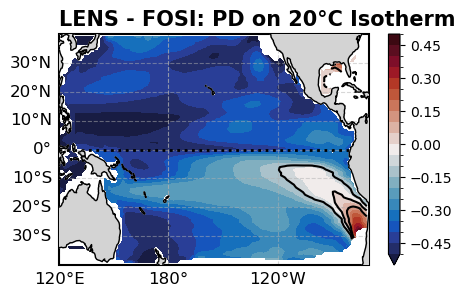

In [39]:
# LENS - FOSI --------- Mean PD on 20°C Isotherm
fig, ax = plt.subplots(figsize=(5, 3), 
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 290, -40, 40], crs=ccrs.PlateCarree())
ax.set_aspect('auto')  # Override the equal aspect ratio

gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 12}  # Longitude labels
gl.ylabel_style = {'size': 12}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='dotted', linewidth=2, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)

diff.sel(lat=slice(-40, 40), lon=slice(120,290)).plot.contourf(vmin=-0.5, vmax=0.5, levels=21,
    cmap=cmocean.cm.balance, transform=ccrs.PlateCarree(), add_colorbar=True)

contour_obj = (diff).plot.contour(levels=[-0.1, 0, 0.1], cmap='k',transform=ccrs.PlateCarree())

plt.title('')
plt.title('LENS - FOSI: PD on 20°C Isotherm', fontsize=15, fontweight='bold', zorder=12, loc='left')
plt.show()

## Potential Density and Depth of 20°C Isotherm on the Equatorial Thermocline

In [39]:
LENS_TEMP_20_depth = LENS_TEMP_all.__xarray_dataarray_variable__.z_t.isel(TEMP=2).mean(dim='time').compute()

In [40]:
FOSI_TEMP_20_depth = FOSI_TEMP.__xarray_dataarray_variable__.z_t.isel(TEMP=2).compute()

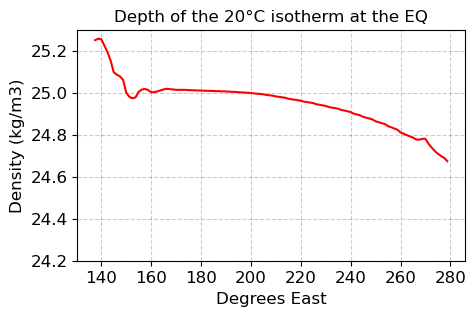

In [48]:
plt.figure(figsize=(5, 3))
mean_114 = regridded_FOSI_PD_nan_noAtlantic.sel(lat=0, method='nearest').isel(lon=slice(110, 280))
x_vals = regridded_FOSI_PD_nan_noAtlantic.sel(lat=0, method='nearest').isel(lon=slice(110, 280)).lon
plt.plot(x_vals, mean_114, c='red', label='LENS')
plt.title('Depth of the 20°C isotherm at the EQ')
plt.ylabel('Density (kg/m3)', fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel('Degrees East', fontsize=12)
plt.grid(c='k', linestyle='dashed', alpha=0.2)
# plt.ylim(24.6, 25.3)
plt.ylim(24.2, 25.3)

plt.show()

In [42]:
mean_114_fosi = (FOSI_TEMP_20_depth.mean(dim='time').isel(nlat_t=114))[20:]

lons = mean_114_fosi.TLONG.data
lats = mean_114_fosi.TLAT.data
depths = mean_114_fosi.data

valid_mask = ~np.isnan(lons) & ~np.isnan(lats) & ~np.isnan(depths)
lons_clean = lons[valid_mask]
lats_clean = lats[valid_mask]
depths_clean = depths[valid_mask]

max_FOSI_val = mean_114.sel(lon=slice(160, 260)).max().data
min_FOSI_val = mean_114.sel(lon=slice(160, 260)).min().data
print(max_FOSI_val)
print(min_FOSI_val)
print(max_FOSI_val - min_FOSI_val)

25.01854776683048
24.810984316266143
0.20756345056433645


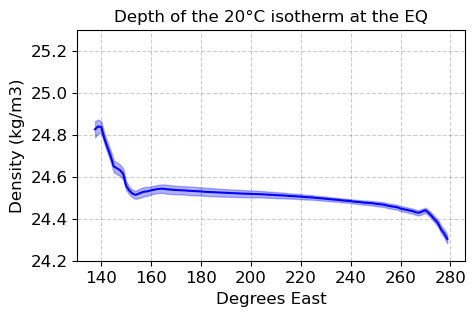

In [49]:
plt.figure(figsize=(5, 3))
mean_114 = regridded_LENS_PD_nan_noAtlantic.sel(lat=0, method='nearest').mean(dim='ensemble').isel(lon=slice(110, 280))
std_114 = regridded_LENS_PD_nan_noAtlantic.sel(lat=0, method='nearest').std(dim='ensemble').isel(lon=slice(110, 280))

x_vals = regridded_LENS_PD_nan_noAtlantic.sel(lat=0, method='nearest').mean(dim='ensemble').isel(lon=slice(110, 280)).lon
plt.plot(x_vals, mean_114, c='blue', label='LENS')

plt.fill_between(x_vals, 
                mean_114 - std_114, 
                mean_114 + std_114, 
                alpha=0.3, color='blue')

plt.title('Depth of the 20°C isotherm at the EQ')
plt.ylabel('Density (kg/m3)', fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel('Degrees East', fontsize=12)
plt.grid(c='k', linestyle='dashed', alpha=0.2)
plt.ylim(24.2, 25.3)
plt.show()

In [53]:
mean_114_fosi = (FOSI_TEMP_20_depth.mean(dim='time').isel(nlat_t=114))[20:]

lons = mean_114_fosi.TLONG.data
lats = mean_114_fosi.TLAT.data
depths = mean_114_fosi.data

valid_mask = ~np.isnan(lons) & ~np.isnan(lats) & ~np.isnan(depths)
lons_clean = lons[valid_mask]
lats_clean = lats[valid_mask]
depths_clean = depths[valid_mask]

max_val = mean_114.sel(lon=slice(160, 260)).max().data
min_val = mean_114.sel(lon=slice(160, 260)).min().data
print(max_val)
print(min_val)
print(max_val - min_val)

24.54269667777529
24.448511234895147
0.09418544288014274


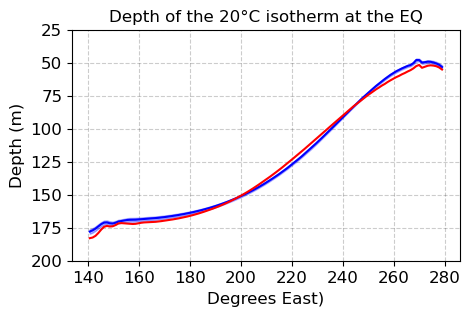

In [55]:
plt.figure(figsize=(5, 3))
mean_114 = (LENS_TEMP_20_depth.mean(dim='ensemble').isel(nlat_t=114)/100)[20:]
std_114 = (LENS_TEMP_20_depth.std(dim='ensemble').isel(nlat_t=114)/100)[20:]

mean_114_fosi = (FOSI_TEMP_20_depth.mean(dim='time').isel(nlat_t=114)/100)[20:]
std_114_fosi = (FOSI_TEMP_20_depth.std(dim='time').isel(nlat_t=114)/100)[20:]

x_vals = LENS_TEMP_20_depth.TLONG.isel(nlat_t=114).data[20:]
plt.plot(x_vals, mean_114, c='blue', label='LENS')
x_vals_fosi = LENS_TEMP_20_depth.TLONG.isel(nlat_t=114).data[20:]
plt.plot(x_vals, mean_114_fosi, c='red', label='FOSI')

plt.fill_between(x_vals, 
                mean_114 - std_114, 
                mean_114 + std_114, 
                alpha=0.3, color='blue')

plt.title('Depth of the 20°C isotherm at the EQ')
plt.ylabel('Depth (m)', fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel('Degrees East)', fontsize=12)
plt.grid(c='k', linestyle='dashed', alpha=0.2)
plt.ylim(200, 25)
plt.show()

## Depth of 20°C Isotherm

In [58]:
regridded_LENS_TEMP_depth = LENS_TEMP_all.__xarray_dataarray_variable__.z_t.mean(
    dim='ensemble').isel(TEMP=2).compute()

In [59]:
regridded_FOSI_TEMP_depth = FOSI_TEMP.__xarray_dataarray_variable__.z_t.isel(TEMP=2).compute()

In [60]:
LENS_mean_TEMP_depth = regridded_LENS_TEMP_depth.mean(dim='time')
LENS_TEMP_depth_1deg = proc_utils.regrid_SMYLE(LENS_mean_TEMP_depth)
regridded_LENS_TEMP_depth = regridder(LENS_TEMP_depth_1deg)

In [61]:
FOSI_mean_TEMP_depth = regridded_FOSI_TEMP_depth.mean(dim='time')
FOSI_TEMP_depth_1deg = proc_utils.regrid_SMYLE(FOSI_mean_TEMP_depth)
regridded_FOSI_TEMP_depth = regridder(FOSI_TEMP_depth_1deg)

In [62]:
diff = regridded_LENS_TEMP_depth - regridded_FOSI_TEMP_depth

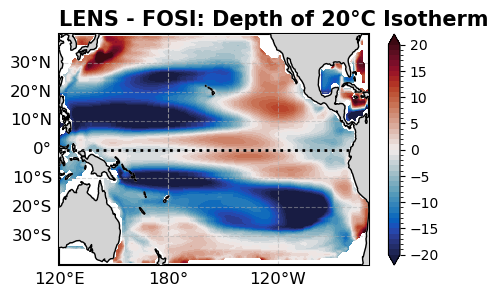

In [63]:
# LENS --------- Mean depth of 20°C Isotherm
fig, ax = plt.subplots(figsize=(5, 3), 
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 290, -40, 40], crs=ccrs.PlateCarree())
ax.set_aspect('auto')  # Override the equal aspect ratio

gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 12}  # Longitude labels
gl.ylabel_style = {'size': 12}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='dotted', linewidth=2, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)

(diff.sel(lat=slice(-40, 40), lon=slice(120,290))/100).plot.contourf(
    vmin=-20, vmax=20, levels=41, cmap=cmocean.cm.balance, transform=ccrs.PlateCarree(), add_colorbar=True)

plt.title('')
plt.title('LENS - FOSI: Depth of 20°C Isotherm', fontsize=15, fontweight='bold', zorder=12, loc='left')
plt.show()

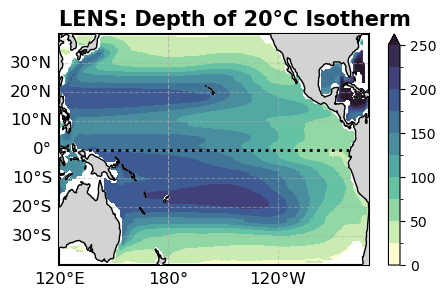

In [64]:
# LENS --------- Mean depth of 20°C Isotherm
fig, ax = plt.subplots(figsize=(5, 3), 
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 290, -40, 40], crs=ccrs.PlateCarree())
ax.set_aspect('auto')  # Override the equal aspect ratio

gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 12}  # Longitude labels
gl.ylabel_style = {'size': 12}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='dotted', linewidth=2, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)

(regridded_LENS_TEMP_depth.sel(lat=slice(-40, 40), lon=slice(120,290))/100).plot.contourf(
    vmin=0, vmax=250, levels=11, cmap=cmocean.cm.deep, transform=ccrs.PlateCarree(), add_colorbar=True)

plt.title('')
plt.title('LENS: Depth of 20°C Isotherm', fontsize=15, fontweight='bold', zorder=12, loc='left')
plt.show()

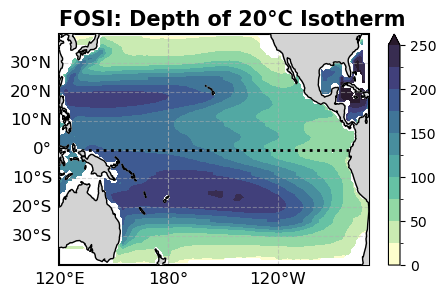

In [65]:
# FOSI --------- Mean depth of 20°C Isotherm
fig, ax = plt.subplots(figsize=(5, 3), 
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 290, -40, 40], crs=ccrs.PlateCarree())
ax.set_aspect('auto')

gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}
ax.axhline(y=0, color='k', linestyle='dotted', linewidth=2, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)

(regridded_FOSI_TEMP_depth.sel(lat=slice(-40, 40), lon=slice(120,290))/100).plot.contourf(
    vmin=0, vmax=250, levels=11, cmap=cmocean.cm.deep, transform=ccrs.PlateCarree(), add_colorbar=True)

plt.title('')
plt.title('FOSI: Depth of 20°C Isotherm', fontsize=15, fontweight='bold', zorder=12, loc='left')
plt.show()

## Potential vorticity

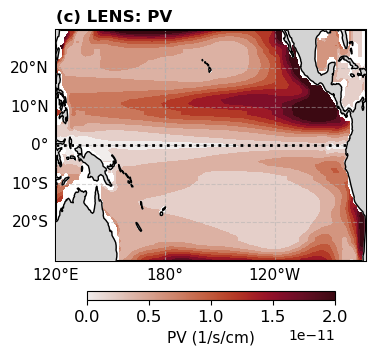

In [60]:
# LENS --------- Mean PV on 20°C Isotherm
fig, ax = plt.subplots(figsize=(4, 4), 
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 290, -30, 30], crs=ccrs.PlateCarree())
ax.set_aspect('auto')  # Override the equal aspect ratio

gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 11}  # Longitude labels
gl.ylabel_style = {'size': 11}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='dotted', linewidth=2, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)

regridded_LENS_PV.mean(dim='ensemble').sel(lat=slice(-30, 30), lon=slice(120,290)).plot.contourf(
    vmin=0, vmax=2e-11, levels=11,
    cmap=cmocean.cm.amp, transform=ccrs.PlateCarree(), add_colorbar=False)

pv_sm = plt.cm.ScalarMappable(cmap=cmocean.cm.amp, norm=plt.Normalize(0, 2e-11))
pv_sm.set_array([])
pv_cbar = plt.colorbar(pv_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
pv_cbar.set_label('PV (1/s/cm)', fontsize=11)
tick_values = np.arange(0, 2.3e-11, 0.5e-11)
pv_cbar.set_ticks(tick_values)
pv_cbar.ax.tick_params(labelsize=12)

plt.title('')
plt.title('(c) LENS: PV', fontsize=12, fontweight='bold', zorder=12, loc='left')
plt.show()

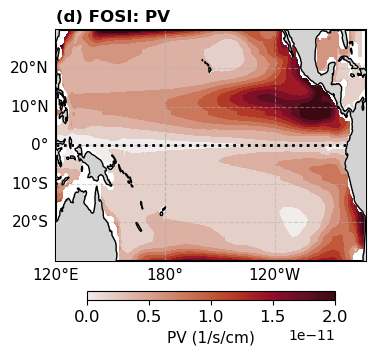

In [62]:
# FOSI --------- Mean PV on 20°C Isotherm
fig, ax = plt.subplots(figsize=(4, 4), 
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 290, -30, 30], crs=ccrs.PlateCarree())
ax.set_aspect('auto')  # Override the equal aspect ratio

gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 11}  # Longitude labels
gl.ylabel_style = {'size': 11}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='dotted', linewidth=2, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)

regridded_FOSI_PV.sel(lat=slice(-30, 30), lon=slice(120,290)).plot.contourf(
    vmin=0, vmax=2e-11, levels=11,
    cmap=cmocean.cm.amp, transform=ccrs.PlateCarree(), add_colorbar=False)

pv_sm = plt.cm.ScalarMappable(cmap=cmocean.cm.amp, norm=plt.Normalize(0, 2e-11))
pv_sm.set_array([])
pv_cbar = plt.colorbar(pv_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
pv_cbar.set_label('PV (1/s/cm)', fontsize=11)
tick_values = np.arange(0, 2.3e-11, 0.5e-11)
pv_cbar.set_ticks(tick_values)
pv_cbar.ax.tick_params(labelsize=12)
plt.title('')

plt.title('(d) FOSI: PV', fontsize=12, fontweight='bold', zorder=12, loc='left')
plt.show()

In [42]:
diff_PV = regridded_LENS_PV - regridded_FOSI_PV

In [43]:
indices = diff_PV.sel(lat=slice(-12, -5), lon=slice(155,240)).mean(dim=('lat','lon')).argsort().data

reordered_list = [ensemble_members[i] for i in indices]
print(reordered_list)
print(ensemble_members)

[90, 85, 49, 68, 73, 80, 61, 0, 32, 65]
[0, 65, 32, 85, 61, 90, 80, 68, 73, 49]


In [44]:
ens_mean = diff_PV.mean(dim='ensemble')

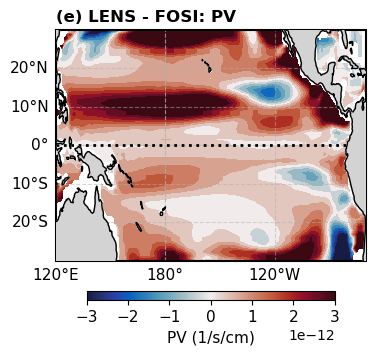

In [64]:
fig, ax = plt.subplots(figsize=(4, 4), 
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 290, -30, 30], crs=ccrs.PlateCarree())
ax.set_aspect('auto')  # Override the equal aspect ratio

gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 11}  # Longitude labels
gl.ylabel_style = {'size': 11}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='dotted', linewidth=2, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)

ens_mean.sel(lat=slice(-40, 40), lon=slice(120,290)).plot.contourf(
    vmin=-0.3e-11, vmax=0.3e-11, levels=16,
    cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(), add_colorbar=False)

# ens_mean.sel(lat=slice(-40, 40), lon=slice(120,290)).plot.contour(
#     levels=[0.3e-12, 0.6e-12, 0.9e-12],
#     cmap='k',transform=ccrs.PlateCarree(), add_colorbar=False)

####### COLORBAR
pv_sm = plt.cm.ScalarMappable(cmap=cmocean.cm.balance, norm=plt.Normalize(-0.3e-11, 0.3e-11))
pv_sm.set_array([])
pv_cbar = plt.colorbar(pv_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
pv_cbar.set_label('PV (1/s/cm)', fontsize=11)
tick_values = np.arange(-0.3e-11, 0.34e-11, 0.1e-11)
pv_cbar.set_ticks(tick_values)
pv_cbar.ax.tick_params(labelsize=11)
plt.title('')
plt.title('(e) LENS - FOSI: PV', fontsize=12, fontweight='bold', zorder=15, loc='left')
plt.show()